In [1]:
import re
from pathlib import Path
import pandas as pd

DATE_FORMAT = "%d-%m-%Y"
date_pat = re.compile(r"(\d{2}-\d{2}-\d{4})")

def extract_date_from_filename(fname: str):
    m = date_pat.search(fname)
    if not m:
        return None
    return pd.to_datetime(m.group(1), format=DATE_FORMAT).normalize()

def load_csvs_in_range(folder: Path, pattern: str, start_date_str: str, end_date_str: str):
    start_date = pd.to_datetime(start_date_str, format=DATE_FORMAT).normalize()
    end_date   = pd.to_datetime(end_date_str,   format=DATE_FORMAT).normalize()

    files = []
    for f in folder.glob(pattern):
        d = extract_date_from_filename(f.name)
        if d is not None and start_date <= d <= end_date:
            files.append((f, d))

    files.sort(key=lambda x: x[1])

    print(f"\n[{folder.name}] Files to read:")
    for f, d in files:
        print(" ", f.name, "->", d.date())

    if not files:
        raise FileNotFoundError(
            f"No files matched {pattern} in {folder} between {start_date.date()} and {end_date.date()}"
        )

    dfs = []
    for f, d in files:
        tmp = pd.read_csv(f)
        tmp["date"] = d
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)

    # Put date first
    df.insert(0, "date", df.pop("date"))

    # If range_m exists, put it second
    if "range_m" in df.columns:
        df.insert(1, "range_m", df.pop("range_m"))

    return df

# -------------------------
# Your inputs
# -------------------------
START_DATE_STR = "05-02-2026"
END_DATE_STR   = "06-02-2026"

# Prototype (CSVeachday)
pro_path = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/")
df_Pro = load_csvs_in_range(
    folder=pro_path,
    pattern="*-2026.csv",               # adjust if you have a specific naming pattern
    start_date_str=START_DATE_STR,
    end_date_str=END_DATE_STR
)

# Commercial MiniMPL (Pict)
mini_path = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/Pict/")
df_MiniMPL = load_csvs_in_range(
    folder=mini_path,
    pattern="MiniMPL_*.csv",
    start_date_str=START_DATE_STR,
    end_date_str=END_DATE_STR
)

print("\n✅ Loaded:")
print("df_Pro     :", df_Pro.shape, "dates:", df_Pro["date"].dt.date.unique())
print("df_MiniMPL :", df_MiniMPL.shape, "dates:", df_MiniMPL["date"].dt.date.unique())


[CSVeachday] Files to read:
  05-02-2026.csv -> 2026-02-05
  06-02-2026.csv -> 2026-02-06

[Pict] Files to read:
  MiniMPL_05-02-2026.csv -> 2026-02-05
  MiniMPL_06-02-2026.csv -> 2026-02-06

✅ Loaded:
df_Pro     : (8000, 50) dates: [datetime.date(2026, 2, 5) datetime.date(2026, 2, 6)]
df_MiniMPL : (576000, 17) dates: [datetime.date(2026, 2, 5) datetime.date(2026, 2, 6)]


In [2]:
df_MiniMPL

,date,range_m,day,timestamp,range_raw,range_m_for_NRB,copol_raw,copol_snr,copol_background,copol_nrb,crosspol_raw,crosspol_snr,crosspol_background,crosspol_nrb,laser_energy,pbls,Normalize_copol_nrb
0,2026-02-05,119.91698,05-02-2026,2026-02-05 00:00:00,0.029979,29.979246,23.303673,75354.720000,0.000678,0.255424,17.973837,61447.418000,0.000646,0.016051,4.241445,2.218464,0.257104
1,2026-02-05,149.89623,05-02-2026,2026-02-05 00:00:00,0.059958,59.958490,10.755943,34772.360000,NaN,0.251261,1.212926,4147.554700,NaN,0.015938,NaN,NaN,0.252913
2,2026-02-05,179.87548,05-02-2026,2026-02-05 00:00:00,0.089938,89.937740,9.981734,32276.646000,NaN,0.255240,0.859720,2939.881000,NaN,0.017122,NaN,NaN,0.256918
3,2026-02-05,209.85472,05-02-2026,2026-02-05 00:00:00,0.119917,119.916980,9.505905,30744.979000,NaN,0.250782,0.762368,2603.734400,NaN,0.016565,NaN,NaN,0.252431
4,2026-02-05,239.83397,05-02-2026,2026-02-05 00:00:00,0.149896,149.896230,8.966919,28992.617000,NaN,0.206652,0.672006,2293.155500,NaN,0.010689,NaN,NaN,0.208011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575995,2026-02-06,NaN,06-02-2026,2026-02-06 23:55:00,29.859330,29859.330000,0.000610,-0.373287,NaN,NaN,0.000684,0.087118,NaN,NaN,NaN,NaN,NaN
575996,2026-02-06,NaN,06-02-2026,2026-02-06 23:55:00,29.889309,29889.309000,0.000788,0.220766,NaN,NaN,0.000699,0.107304,NaN,NaN,NaN,NaN,NaN
575997,2026-02-06,NaN,06-02-2026,2026-02-06 23:55:00,29.919287,29919.287000,0.000610,-0.364503,NaN,NaN,0.000550,-0.353151,NaN,NaN,NaN,NaN,NaN
575998,2026-02-06,NaN,06-02-2026,2026-02-06 23:55:00,29.949266,29949.266000,0.000848,0.369105,NaN,NaN,0.000521,-0.445106,NaN,NaN,NaN,NaN,NaN


In [3]:
df_Pro

,date,range_m,00.05,00.35,01.05,01.35,02.05,02.35,03.05,03.35,...,19.05,19.35,20.05,20.35,21.05,21.35,22.05,22.35,23.05,23.35
0,2026-02-05,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2026-02-05,3.75,0.000094,0.000105,0.000167,0.000170,0.000074,0.000146,0.000134,0.000097,...,0.000118,0.000006,0.000135,0.000159,0.000116,0.000159,0.000125,0.000089,0.000061,0.000164
2,2026-02-05,7.50,0.000802,0.000939,0.001889,0.001977,0.000519,0.001543,0.001381,0.000905,...,0.001242,0.000042,0.001938,0.001943,0.001146,0.001977,0.001337,0.000778,0.000407,0.001961
3,2026-02-05,11.25,0.002668,0.003035,0.006072,0.006211,0.001494,0.004783,0.004583,0.002905,...,0.004406,0.000135,0.006683,0.006481,0.003859,0.006567,0.004781,0.002652,0.001228,0.006385
4,2026-02-05,15.00,0.004742,0.005390,0.010781,0.011027,0.002653,0.008492,0.008134,0.005159,...,0.007831,0.000239,0.011868,0.011506,0.006850,0.011659,0.008495,0.004713,0.002182,0.011338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,2026-02-06,14981.25,0.113614,0.001938,-0.088010,-0.100391,-0.104716,0.089034,-0.012306,0.072420,...,-0.006986,-0.001771,-0.098313,0.183223,-0.004984,0.078393,-0.099717,-0.096715,0.081740,-0.106717
7996,2026-02-06,14985.00,-0.115043,-0.093788,-0.088055,-0.009299,0.083195,-0.108495,-0.116187,0.072456,...,-0.088011,-0.096224,0.165101,0.088234,-0.087045,-0.102607,-0.011695,-0.096764,0.081781,-0.006753
7997,2026-02-06,14988.75,-0.115101,0.001940,-0.088099,-0.100492,-0.010792,-0.108549,-0.012318,0.154523,...,-0.088055,-0.096273,0.077318,-0.101980,-0.004989,-0.012094,-0.011701,-0.004765,0.081822,-0.006756
7998,2026-02-06,14992.50,-0.000687,-0.093882,0.069462,-0.100542,0.083278,-0.108604,-0.116303,-0.009543,...,-0.088099,-0.096321,-0.010552,-0.102031,-0.087133,-0.012100,0.076455,-0.096861,-0.087715,-0.006759


In [4]:
# allow str or datetime
start_date = pd.to_datetime(START_DATE_STR, format="%d-%m-%Y")
end_date   = pd.to_datetime(END_DATE_STR, format="%d-%m-%Y")

# --- ensure datetime + filter ---
df_Pro["date"] = pd.to_datetime(df_Pro["date"], errors="coerce")
df_Pro_sel = df_Pro.loc[
    df_Pro["date"].between(start_date, end_date, inclusive="both")
].copy()

# 4) Wide → long format
time_cols = [
    c for c in df_Pro_sel.columns
    if re.fullmatch(r"\d{1,2}\.\d{2}", str(c))
]

df_Pro_long = df_Pro_sel.melt(
    id_vars=["date", "range_m"],
    value_vars=time_cols,
    var_name="time",
    value_name="signal"
)

bad_time = df_Pro_long.loc[
    ~df_Pro_long["time"].astype(str).str.match(r"^\d{1,2}\.\d{2}$"),
    "time"
]
print(bad_time.value_counts().head(30))

# 5) Build datetime (date + HH.MM)
df_Pro_long["datetime"] = pd.to_datetime(
    df_Pro_long["date"].dt.strftime("%Y-%m-%d") + " " +
    df_Pro_long["time"].astype(str).str.replace(".", ":", regex=False),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# 6) Pivot to 2D grid (range × time)
df_Pro_long = df_Pro_long.dropna(
    subset=["range_m", "signal", "datetime"]
)

Z_NRB_Pro = df_Pro_long.pivot(
    index="range_m",
    columns="datetime",
    values="signal"
).sort_index()

Series([], Name: count, dtype: int64)


In [5]:
# 1) Ensure datetime + numeric
df_MiniMPL = df_MiniMPL.copy()

df_MiniMPL["timestamp"] = pd.to_datetime(df_MiniMPL["timestamp"], errors="coerce")

num_cols = [
    "range_m_for_NRB",
    "copol_nrb",
]

for c in num_cols:
    if c in df_MiniMPL.columns:
        df_MiniMPL[c] = pd.to_numeric(df_MiniMPL[c], errors="coerce")

# 2) Filter by date range (inclusive)
start_ts = pd.to_datetime(start_date)
end_ts   = pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

df_sel = df_MiniMPL.loc[
    df_MiniMPL["timestamp"].between(start_ts, end_ts, inclusive="both")
].copy()

# 3) Drop NaNs (only required columns)
need_cols = ["timestamp", "range_m_for_NRB", "copol_nrb"]
df_sel = df_sel.dropna(subset=need_cols)

# 4) Pivot to curtain matrix (NRB co only)
Z_NRB_MiniMPL = df_sel.pivot(
    index="range_m_for_NRB",
    columns="timestamp",
    values="copol_nrb"
).sort_index()

print("Curtain shape NRB co:", Z_NRB_MiniMPL.shape)

Curtain shape NRB co: (664, 576)


In [6]:
def plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="figures",
    ylim=None,
    xlim=None,
    clim=None,
    cmap="jet",
    invert_y=False,
):
    """
    Z : 2D DataFrame (range_m × datetime)

    scale : "linear" or "log"
    ylim  : tuple (ymin, ymax) or None
    xlim  : tuple (xmin, xmax) datetime or None
    clim  : tuple (vmin, vmax) or None
    cmap  : matplotlib colormap
    invert_y : True/False
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # --- Scale handling ---
    if scale == "log":
        Z_plot = np.log10(Z.clip(lower=1e-6))
        color_label = "log₁₀(Signal)"
        title_scale = "log10"
    elif scale == "linear":
        Z_plot = Z.copy()
        color_label = "Signal"
        title_scale = "Linear"
    else:
        raise ValueError("scale must be 'linear' or 'log'")

    fig, ax = plt.subplots(figsize=(14, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns,
        Z_plot.index,
        Z_plot.values,
        shading="auto",
        cmap=cmap
    )

    # --- Time formatting ---
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d %b %Y\n%H:%M')
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")

    # --- Optional axis limits ---
    if ylim is not None:
        ax.set_ylim(ylim)

    if xlim is not None:
        ax.set_xlim(xlim)

    if invert_y:
        ax.invert_yaxis()

    # --- Optional color limits ---
    if clim is not None:
        pcm.set_clim(*clim)

    ax.set_title(
        f"Lidar Backscatter ({title_scale}): "
        f"{start_date:%d %b %Y %H:%M} – {end_date:%d %b %Y %H:%M}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)

    plt.tight_layout()

    # --- Save section ---
    if save:
        os.makedirs(save_dir, exist_ok=True)

        filename = (
            f"lidar_{title_scale}_MPL"
            f"{start_date:%Y%m%d_%H%M}_"
            f"{end_date:%Y%m%d_%H%M}.png"
        )

        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Saved figure → {save_path}")

    plt.show()


In [7]:
print("Z shape:", Z_NRB_Pro.shape)
print("time min/max:", Z_NRB_Pro.columns.min(), "->", Z_NRB_Pro.columns.max())
print("range min/max:", Z_NRB_Pro.index.min(), "->", Z_NRB_Pro.index.max())

Z shape: (4000, 96)
time min/max: 2026-02-05 00:05:00 -> 2026-02-06 23:35:00
range min/max: 0.0 -> 14996.25


Saved figure → figures/lidar_Linear_MPL20260205_0000_20260206_0000.png


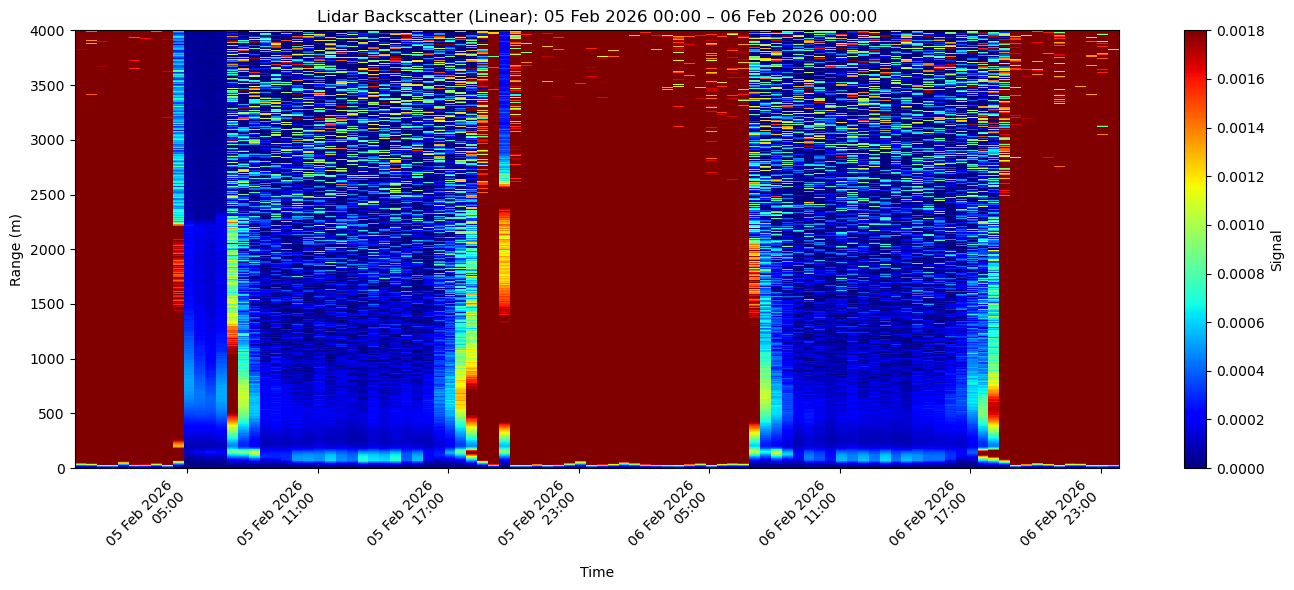

In [40]:
plot_lidar_curtain(
    Z_NRB_Pro/25,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 4000),
    clim=(0, 0.0018)
)

Saved figure → figures/lidar_Linear_MPL20260205_0000_20260206_0000.png


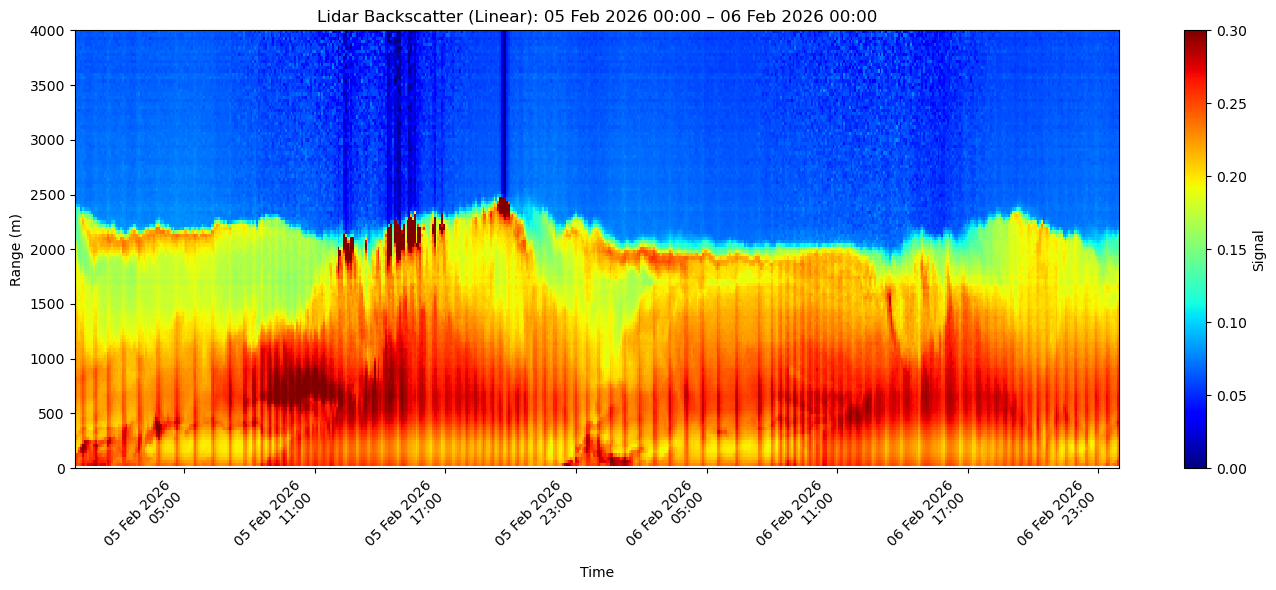

In [9]:
plot_lidar_curtain(
    Z_NRB_MiniMPL,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 4000),
    clim=(0, 0.3)
)

In [10]:
Z_NRB_Pro.columns = pd.to_datetime(Z_NRB_Pro.columns)
Z_NRB_MiniMPL.columns = pd.to_datetime(Z_NRB_MiniMPL.columns)

common_time = Z_NRB_Pro.columns.intersection(Z_NRB_MiniMPL.columns)

print("Prototype time count:", len(Z_NRB_Pro.columns))
print("MiniMPL time count before:", len(Z_NRB_MiniMPL.columns))
print("Matched time count:", len(common_time))

Zp = Z_NRB_Pro[common_time]
Zm = Z_NRB_MiniMPL[common_time]

Prototype time count: 96
MiniMPL time count before: 576
Matched time count: 96


In [11]:
Z_NRB_Pro

datetime,2026-02-05 00:05:00,2026-02-05 00:35:00,2026-02-05 01:05:00,2026-02-05 01:35:00,2026-02-05 02:05:00,2026-02-05 02:35:00,2026-02-05 03:05:00,2026-02-05 03:35:00,2026-02-05 04:05:00,2026-02-05 04:35:00,...,2026-02-06 19:05:00,2026-02-06 19:35:00,2026-02-06 20:05:00,2026-02-06 20:35:00,2026-02-06 21:05:00,2026-02-06 21:35:00,2026-02-06 22:05:00,2026-02-06 22:35:00,2026-02-06 23:05:00,2026-02-06 23:35:00
range_m,,,,,,,,,,,,,,,,,,,,,
0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3.75,0.000094,0.000105,0.000167,0.000170,0.000074,0.000146,0.000134,0.000097,0.000152,0.000025,...,0.000146,0.000111,0.000088,0.000108,0.000160,0.000098,0.000097,0.000154,0.000153,0.000138
7.50,0.000802,0.000939,0.001889,0.001977,0.000519,0.001543,0.001381,0.000905,0.001905,0.000320,...,0.001885,0.001092,0.000750,0.001030,0.002052,0.000899,0.000892,0.001935,0.001999,0.001517
11.25,0.002668,0.003035,0.006072,0.006211,0.001494,0.004783,0.004583,0.002905,0.006460,0.001079,...,0.006447,0.003795,0.002518,0.003359,0.006621,0.002957,0.003031,0.006422,0.006612,0.004952
15.00,0.004742,0.005390,0.010781,0.011027,0.002653,0.008492,0.008134,0.005159,0.011471,0.001916,...,0.011447,0.006743,0.004475,0.005963,0.011752,0.005253,0.005384,0.011401,0.011739,0.008791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14981.25,0.176501,-0.018826,-0.131720,0.107633,-0.101286,-0.124907,0.081681,0.159250,-0.103163,0.011433,...,-0.006986,-0.001771,-0.098313,0.183223,-0.004984,0.078393,-0.099717,-0.096715,0.081740,-0.106717
14985.00,-0.117041,-0.018835,0.112371,-0.125532,-0.019120,-0.124970,-0.120759,0.071820,-0.011552,-0.003496,...,-0.088011,-0.096224,0.165101,0.088234,-0.087045,-0.102607,-0.011695,-0.096764,0.081781,-0.006753
14988.75,-0.019174,-0.018845,-0.131852,-0.125595,-0.019130,-0.014142,-0.120820,-0.015698,0.080150,-0.018439,...,-0.088055,-0.096273,0.077318,-0.101980,-0.004989,-0.012094,-0.011701,-0.004765,0.081822,-0.006756


In [12]:
Z_NRB_MiniMPL

timestamp,2026-02-05 00:00:00,2026-02-05 00:05:00,2026-02-05 00:10:00,2026-02-05 00:15:00,2026-02-05 00:20:00,2026-02-05 00:25:00,2026-02-05 00:30:00,2026-02-05 00:35:00,2026-02-05 00:40:00,2026-02-05 00:45:00,...,2026-02-06 23:10:00,2026-02-06 23:15:00,2026-02-06 23:20:00,2026-02-06 23:25:00,2026-02-06 23:30:00,2026-02-06 23:35:00,2026-02-06 23:40:00,2026-02-06 23:45:00,2026-02-06 23:50:00,2026-02-06 23:55:00
range_m_for_NRB,,,,,,,,,,,,,,,,,,,,,
29.979246,0.255424,0.245572,0.248185,0.258951,0.275106,0.266251,0.264837,0.273093,0.271934,0.277528,...,0.223487,0.224616,0.231911,0.252330,0.242960,0.228529,0.233262,0.239887,0.238054,0.255824
59.958490,0.251261,0.243041,0.239975,0.249087,0.268085,0.259564,0.257895,0.256901,0.260972,0.263073,...,0.217176,0.215735,0.220019,0.239018,0.239014,0.222571,0.218972,0.224938,0.227443,0.255993
89.937740,0.255240,0.251123,0.237106,0.241078,0.264553,0.254583,0.253478,0.244962,0.256808,0.255671,...,0.211186,0.210396,0.213911,0.233081,0.230946,0.219518,0.213525,0.212127,0.215608,0.241980
119.916980,0.250782,0.253717,0.245436,0.248378,0.275337,0.256469,0.254507,0.242778,0.254428,0.251575,...,0.207949,0.206468,0.210795,0.229590,0.225078,0.211984,0.207123,0.206662,0.209066,0.232828
149.896230,0.206652,0.214146,0.254444,0.273307,0.300870,0.273914,0.273769,0.249812,0.254037,0.246296,...,0.204987,0.203218,0.209114,0.230958,0.223026,0.208485,0.201946,0.201269,0.203958,0.227973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19786.303000,0.006655,-0.009929,-0.001089,0.014281,0.012337,0.016209,0.010815,-0.007192,0.029656,-0.002855,...,-0.000809,0.014955,0.013258,0.010401,-0.005277,0.010430,0.015151,0.001687,-0.001430,0.021729
19816.282000,0.008643,-0.006786,-0.000783,0.003843,-0.017019,0.008279,0.007130,0.001392,0.004194,0.008166,...,0.026998,0.012613,-0.005093,0.010697,0.004801,-0.001608,-0.015900,0.012736,-0.001233,0.001860
19846.260000,0.017553,-0.002097,-0.013684,0.005917,0.008363,-0.006722,0.018855,0.017349,-0.007547,0.014233,...,0.001529,0.003872,-0.003050,0.001874,-0.011317,0.012835,0.029937,0.005263,0.006207,0.006548


In [13]:
import numpy as np
import pandas as pd

def bin_by_range(Z, bin_m=30):
    Zb = Z.copy()
    Zb.index = pd.to_numeric(Zb.index, errors="coerce")
    Zb = Zb.sort_index()
    
    # สร้าง bin เช่น 0, 30, 60, ...
    bins = (np.floor(Zb.index / bin_m) * bin_m).astype(int)
    Zb.index = bins
    
    return Zb.groupby(level=0).mean()

Zp_b = bin_by_range(Zp, bin_m=30)
Zm_b = bin_by_range(Zm, bin_m=30)

common_range = Zp_b.index.intersection(Zm_b.index)

print("common_range after bin:", len(common_range))

X = Zp_b.loc[common_range].to_numpy().ravel()
Y = Zm_b.loc[common_range].to_numpy().ravel()

mask = np.isfinite(X) & np.isfinite(Y)

print("valid paired:", mask.sum())

r = np.corrcoef(X[mask], Y[mask])[0,1]
print("r =", r)



common_range after bin: 500
valid paired: 48000
r = 0.21883637141499615


valid paired (after cut Y<=0.5): 9680
r = 0.27893544581248136


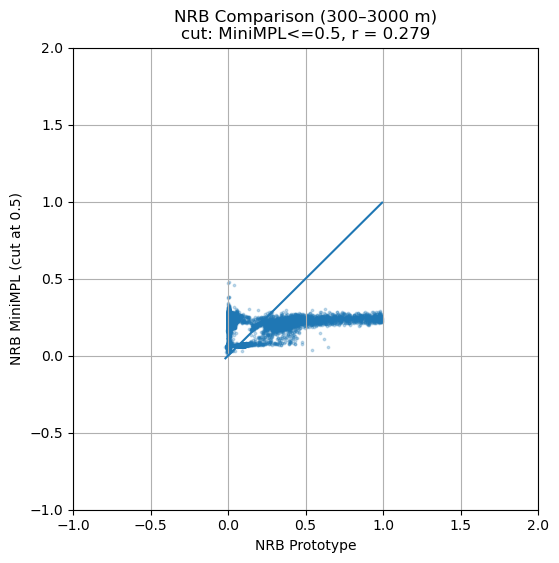

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1) select range window separately (no boolean mask sharing)
Zp_sel = Zp_b.loc[0:3000]
Zm_sel = Zm_b.loc[0:3000]

# 2) make sure same range bins
common_range = Zp_sel.index.intersection(Zm_sel.index)
Zp_sel = Zp_sel.loc[common_range]
Zm_sel = Zm_sel.loc[common_range]

# 3) flatten
X = Zp_sel.to_numpy().ravel()
Y = Zm_sel.to_numpy().ravel()

# --- CUT RULE: drop MiniMPL values > 0.5 ---
mask = np.isfinite(X) & np.isfinite(Y) & (Y <= 0.5)

print("valid paired (after cut Y<=0.5):", int(mask.sum()))

r = np.corrcoef(X[mask], Y[mask])[0, 1]
print("r =", r)

# 4) plot
plt.figure(figsize=(6,6))
plt.scatter(X[mask], Y[mask], s=3, alpha=0.25)

mn = float(min(X[mask].min(), Y[mask].min()))
mx = float(max(X[mask].max(), Y[mask].max()))
plt.plot([mn, mx], [mn, mx])
plt.xlim(-1, 2)
plt.ylim(-1, 2)
plt.xlabel("NRB Prototype")
plt.ylabel("NRB MiniMPL (cut at 0.5)")
plt.title(f"NRB Comparison (300–3000 m)\ncut: MiniMPL<=0.5, r = {r:.3f}")
plt.grid(True)
plt.show()

common_range bins: 500
valid paired: 48000
r = 0.21883637141499615


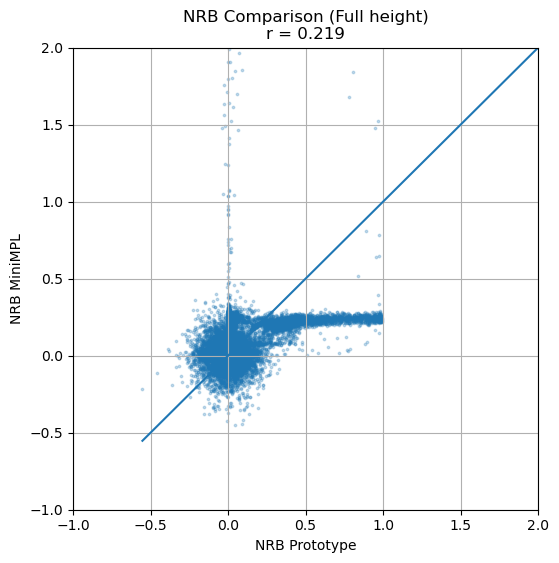

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Make sure time is already matched
# Zp_b and Zm_b should already have common_time

# 2) Align range using intersection (no slicing)
common_range = Zp_b.index.intersection(Zm_b.index)

print("common_range bins:", len(common_range))

Zp_sel = Zp_b.loc[common_range]
Zm_sel = Zm_b.loc[common_range]

# 3) Flatten
X = Zp_sel.to_numpy().ravel()
Y = Zm_sel.to_numpy().ravel()

mask = np.isfinite(X) & np.isfinite(Y)
print("valid paired:", mask.sum())

# 4) Correlation
r = np.corrcoef(X[mask], Y[mask])[0,1]
print("r =", r)

# 5) Plot
plt.figure(figsize=(6,6))
plt.scatter(X[mask], Y[mask], s=3, alpha=0.25)

mn = float(min(X[mask].min(), Y[mask].min()))
mx = float(max(X[mask].max(), Y[mask].max()))
plt.plot([mn, mx], [mn, mx])
plt.xlim(-1, 2)
plt.ylim(-1, 2)
plt.xlabel("NRB Prototype")
plt.ylabel("NRB MiniMPL")
plt.title(f"NRB Comparison (Full height)\nr = {r:.3f}")
plt.grid(True)
plt.show()

In [16]:
print((Zp.columns == Zm.columns).all())
print(len(Zp.columns), len(Zm.columns))

True
96 96
